# Лабораторная работа N2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from scipy.stats import zscore
from my_metrics_regres import *

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from math import sqrt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, BayesianRidge, RANSACRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline


RNG_SEED = 42
np.random.seed(seed=RNG_SEED)

## Загрузка данных

In [2]:
data = pd.read_csv('../data/final_data_diamonds.csv')
data.drop(['Unnamed: 0'], axis=1, inplace=True)
print(f"Размер датасета: {data.shape}")
data

Размер датасета: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.199341,4,5,1,-0.176255,-1.096824,326,-1.587838,-1.573373,-1.593630
1,-1.241582,3,5,2,-1.381334,1.591635,326,-1.641325,-1.699002,-1.766179
2,-1.199341,1,5,4,-3.437056,3.383941,327,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461729,0.247406,334,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099711,0.247406,335,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672465,-0.200671,2757,0.016798,0.023909,-0.055076
53936,-0.164447,1,6,2,0.957936,-1.096824,2757,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745276,1.143559,2757,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530690,0.247406,2757,0.373383,0.346954,0.290021


## Выделение целевого признака и предикторов

In [3]:
y = data["price"]
X = data.drop(["price"], axis=1)

print(f"Целевая переменная (y): {y.shape}")
print(f"Признаки (X): {X.shape}")

X.head()

Целевая переменная (y): (53940,)
Признаки (X): (53940, 9)


,carat,cut,color,clarity,depth,table,x,y,z
0,-1.199341,4,5,1,-0.176255,-1.096824,-1.587838,-1.573373,-1.593630
1,-1.241582,3,5,2,-1.381334,1.591635,-1.641325,-1.699002,-1.766179
2,-1.199341,1,5,4,-3.437056,3.383941,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461729,0.247406,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099711,0.247406,-1.240166,-1.241354,-1.133502


## разделение данных на обучающую и тестовую выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_simple, X_test_simple = X_train[["carat"]], X_test[["carat"]]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (43152, 9), y_train: (43152,)
X_test: (10788, 9), y_test: (10788,)


In [5]:
# вспомогательная функция расчета вывода метрик
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    stats = {
        'R^2': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }
        
    return stats

## Решение задачи регрессии (простая линейная)

### Линейная регрессия

In [6]:
lr_simple = LinearRegression().fit(X_train_simple, y_train)

y_train_pred = lr_simple.predict(X_train_simple)
y_test_pred = lr_simple.predict(X_test_simple)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8502175175936595, 'MSE': 2384497.9883338907, 'RMSE': 1544.181980316404, 'MAE': 1009.1436515533801, 'MAPE': 0.382661759554091}
{'R^2': 0.8502269303268636, 'MSE': 2380915.746800916, 'RMSE': 1543.021628753439, 'MAE': 1009.8701278657967, 'MAPE': 0.39096980433112893}


In [7]:
print(f"\nКоличество коэффициентов: {len(lr_simple.coef_)}")
print(f"Коэффициенты: {lr_simple.coef_}")
print(f"Свободный член (intercept): {lr_simple.intercept_:.2f}")


Количество коэффициентов: 1
Коэффициенты: [3683.88362398]
Свободный член (intercept): 3937.14


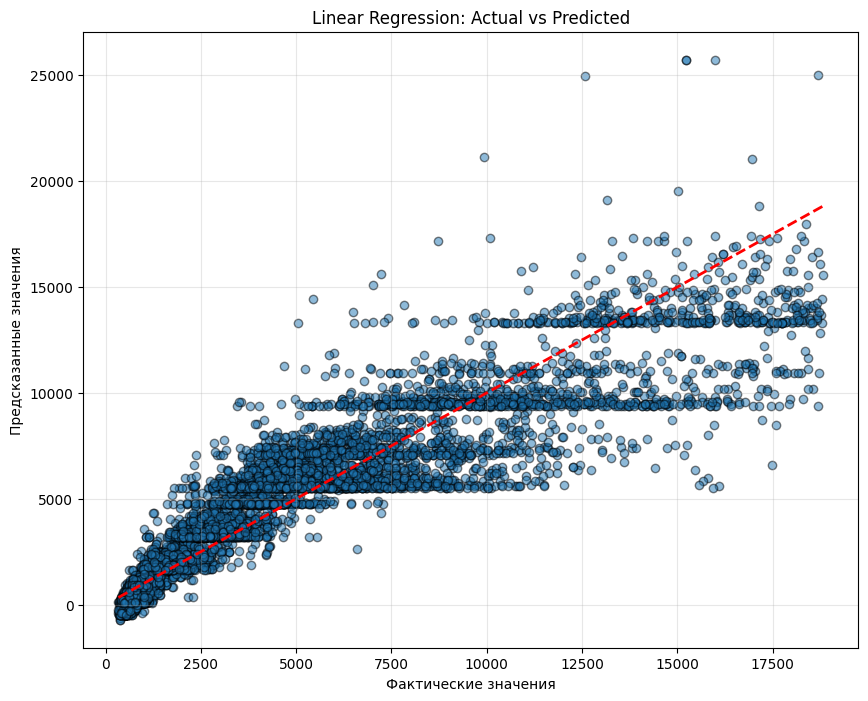

In [8]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(True, alpha=0.3)
plt.show()

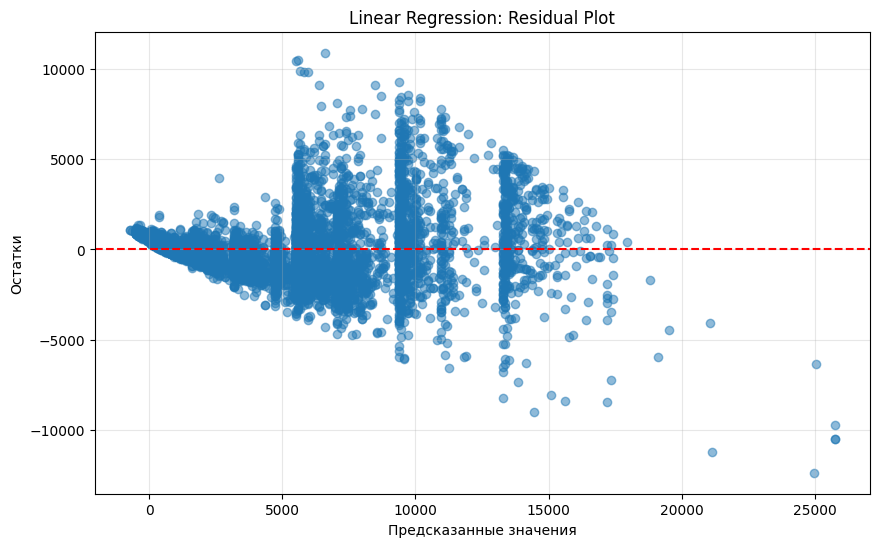

In [9]:
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Linear Regression: Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()

### Lasso

In [10]:
parameters = {'alpha': np.arange(0.1, 1, 0.1)}

In [11]:
lasso_grid_simple = GridSearchCV(Lasso(max_iter=10000), parameters).fit(X_train_simple, y_train)
print(f"GridSearch: {lasso_grid_simple.best_params_}")

GridSearch: {'alpha': 0.2}


In [12]:
lasso_random_simple = RandomizedSearchCV(Lasso(max_iter=10000), parameters).fit(X_train_simple, y_train)
print(f"Randomized: {lasso_random_simple.best_params_}")

c:\Users\danii\Desktop\git\master\mlbd\venv\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Randomized: {'alpha': 0.2}


In [13]:

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2)
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_simple, y_train)
    y_pred = model.predict(X_test_simple)
    mse = mean_squared_error(y_test, y_pred)
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=False)

best_params = study.best_params
print(f"Optuna: {best_params}")

Optuna: {'alpha': 26.45604863661353}


In [14]:
random_lasso_simple = Lasso(alpha=0.2)
random_lasso_simple.fit(X_train_simple, y_train)

y_train_pred = random_lasso_simple.predict(X_train_simple)
y_test_pred = random_lasso_simple.predict(X_test_simple)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8502175150744176, 'MSE': 2384498.028439564, 'RMSE': 1544.1819933024617, 'MAE': 1009.1026364091703, 'MAPE': 0.38259625408049835}
{'R^2': 0.8502276024500781, 'MSE': 2380905.0621781815, 'RMSE': 1543.018166509449, 'MAE': 1009.8242916323153, 'MAPE': 0.39090007418881967}


In [15]:
optuna_lasso_simple = Lasso(alpha=best_params['alpha'])
optuna_lasso_simple.fit(X_train_simple, y_train)

y_train_pred = optuna_lasso_simple.predict(X_train_simple)
y_test_pred = optuna_lasso_simple.predict(X_test_simple)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8501734357405123, 'MSE': 2385199.759919344, 'RMSE': 1544.4091944557128, 'MAE': 1003.9120867267458, 'MAPE': 0.3741549339616863}
{'R^2': 0.8502714484682165, 'MSE': 2380208.049856487, 'RMSE': 1542.792289926446, 'MAE': 1004.0806094947267, 'MAPE': 0.381944730687702}


### Ridge

In [16]:
parameters = {'alpha': np.arange(0, 1, 0.1)}
ridge_grid_simple = GridSearchCV(Ridge(), parameters).fit(X_train_simple, y_train)
print(f"GridSearch: {ridge_grid_simple.best_params_}")

ridge_random = RandomizedSearchCV(Ridge(), parameters).fit(X_train_simple, y_train)
print(f"Randomized: {ridge_random.best_params_}")

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2)
    model = Ridge(alpha=alpha)
    model.fit(X_train_simple, y_train)
    y_pred = model.predict(X_test_simple)
    mse = mean_squared_error(y_test, y_pred)
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=False)

best_params = study.best_params
print(f"optuna: {best_params}")

GridSearch: {'alpha': 0.9}
Randomized: {'alpha': 0.9}
optuna: {'alpha': 99.99778630821008}


In [17]:
random_Ridge_simple = Ridge(alpha=0.9)
random_Ridge_simple.fit(X_train_simple, y_train)

y_train_pred = random_Ridge_simple.predict(X_train_simple)
y_test_pred = random_Ridge_simple.predict(X_test_simple)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8502175172218789, 'MSE': 2384497.9942525406, 'RMSE': 1544.1819822328393, 'MAE': 1009.1278953111762, 'MAPE': 0.3826365951879164}
{'R^2': 0.8502271891322433, 'MSE': 2380911.6326180054, 'RMSE': 1543.0202955949756, 'MAE': 1009.8525195698767, 'MAPE': 0.39094301703018686}


In [18]:
optuna_Ridge_simple = Ridge(alpha=best_params['alpha'])
optuna_Ridge_simple.fit(X_train_simple, y_train)

y_train_pred = optuna_Ridge_simple.predict(X_train_simple)
y_test_pred = optuna_Ridge_simple.predict(X_test_simple)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8502129489760479, 'MSE': 2384570.7195326886, 'RMSE': 1544.205530210499, 'MAE': 1007.4153362639037, 'MAPE': 0.379886916506424}
{'R^2': 0.8502510259561287, 'MSE': 2380532.7028847323, 'RMSE': 1542.8975023911123, 'MAE': 1007.9491379569105, 'MAPE': 0.38802171443035477}


### Elastic Net

In [19]:
parameters = {'alpha': np.arange(0.1, 1, 0.1), 'l1_ratio': np.arange(0.1, 1, 0.1)}

In [20]:
elastic_grid_simple = GridSearchCV(ElasticNet(max_iter=10000), parameters, cv=5).fit(X_train_simple, y_train)
print(f"GridSearch: {elastic_grid_simple.best_params_}")

GridSearch: {'alpha': 0.1, 'l1_ratio': 0.9}


In [21]:
elastic_random_simple = RandomizedSearchCV(ElasticNet(max_iter=10000), parameters, n_iter=50, cv=5).fit(X_train_simple, y_train)
print(f"Randomized: {elastic_random_simple.best_params_}")

Randomized: {'l1_ratio': 0.8, 'alpha': 0.1}


In [22]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 1.0)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
    model.fit(X_train_simple, y_train)
    y_pred = model.predict(X_test_simple)
    mse = mean_squared_error(y_test, y_pred)
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=False)

best_params = study.best_params
print(f"Optuna: {best_params}")

Optuna: {'alpha': 0.008809356205383263, 'l1_ratio': 0.1776473100972773}


In [23]:
random_ElasticNet_simple = ElasticNet(alpha=0.8, l1_ratio=0.1)
random_ElasticNet_simple.fit(X_train_simple, y_train)

y_train_pred = random_ElasticNet_simple.predict(X_train_simple)
y_test_pred = random_ElasticNet_simple.predict(X_test_simple)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.7007675045441482, 'MSE': 4763703.151366681, 'RMSE': 2182.5909262540886, 'MAE': 1514.680443605704, 'MAPE': 0.7616218318900394}
{'R^2': 0.7037807016702193, 'MSE': 4708945.2959659295, 'RMSE': 2170.0104368334105, 'MAE': 1500.8873546600075, 'MAPE': 0.7661286458524048}


In [24]:
optuna_ElasticNet_simple = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=10000)
optuna_ElasticNet_simple.fit(X_train_simple, y_train)

y_train_pred = optuna_ElasticNet_simple.predict(X_train_simple)
y_test_pred = optuna_ElasticNet_simple.predict(X_test_simple)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8501733004207858, 'MSE': 2385201.914174038, 'RMSE': 1544.4098918920579, 'MAE': 1003.904343714904, 'MAPE': 0.37414208998356524}
{'R^2': 0.8502714480402015, 'MSE': 2380208.0566605646, 'RMSE': 1542.7922921315637, 'MAE': 1004.072050698524, 'MAPE': 0.3819311453076564}


## Решение задачи регрессии (множественная)

### Линейная регрессия

In [25]:
lr = LinearRegression().fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.9088125850287099, 'MSE': 1451679.8230819323, 'RMSE': 1204.856764550016, 'MAE': 803.7822854161642, 'MAPE': 0.43800983818073064}
{'R^2': 0.908310705543756, 'MSE': 1457568.3429628785, 'RMSE': 1207.2979511963392, 'MAE': 801.2618177815951, 'MAPE': 0.44422872096676336}


In [26]:
print(f"\nКоличество коэффициентов: {len(lr.coef_)}")
print(f"Коэффициенты: {lr.coef_}")
print(f"Свободный член (intercept): {lr.intercept_:.2f}")


Количество коэффициентов: 9
Коэффициенты: [ 5180.26384213   125.49166195   324.71574465   500.72236836
  -105.13734575   -56.01763328 -1524.01448947   572.16530025
   -86.01235544]
Свободный член (intercept): 936.72


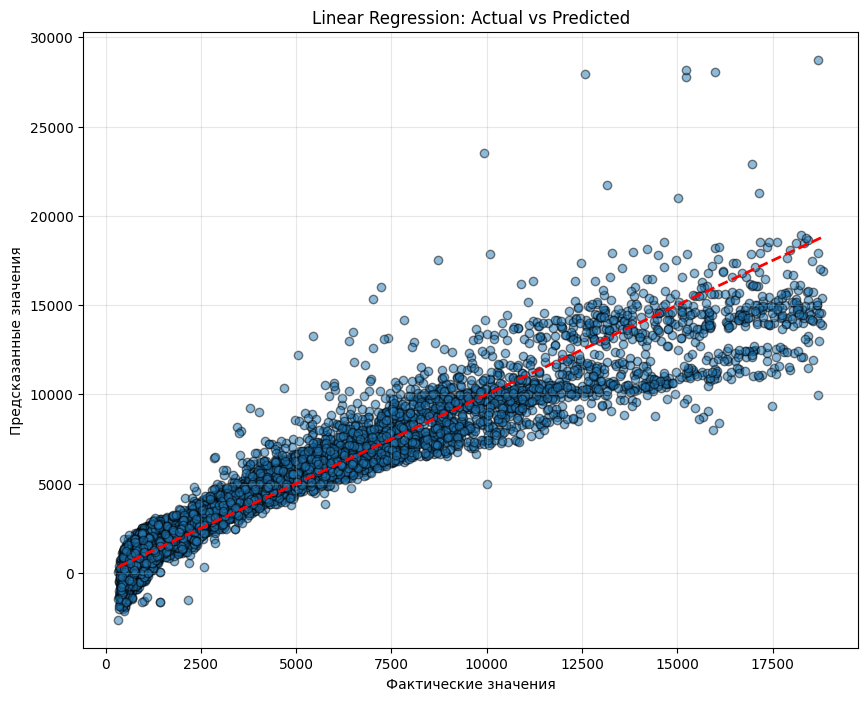

In [27]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(True, alpha=0.3)
plt.show()

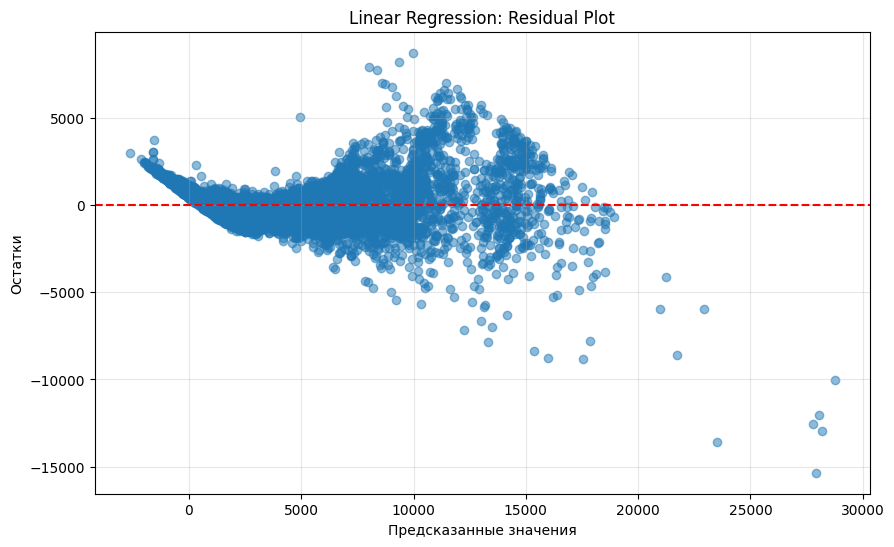

In [28]:
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Linear Regression: Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()

### Lasso

In [29]:
parameters = {'alpha': np.arange(0.1, 1, 0.1)}

In [30]:
lasso_grid = GridSearchCV(Lasso(max_iter=10000), parameters).fit(X_train, y_train)
print(f"GridSearch: {lasso_grid.best_params_}")

GridSearch: {'alpha': 0.4}


In [31]:
lasso_random = RandomizedSearchCV(Lasso(max_iter=10000), parameters).fit(X_train, y_train)
print(f"Randomized: {lasso_random.best_params_}")

c:\Users\danii\Desktop\git\master\mlbd\venv\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Randomized: {'alpha': 0.4}


In [32]:

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2)
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=False)

best_params = study.best_params
print(f"Optuna: {best_params}")

Optuna: {'alpha': 0.011821004816816583}


In [33]:
random_lasso = Lasso(alpha=0.4)
random_lasso.fit(X_train, y_train)

y_train_pred = random_lasso.predict(X_train)
y_test_pred = random_lasso.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.9088040928086338, 'MSE': 1451815.0170068995, 'RMSE': 1204.9128669770687, 'MAE': 804.0872762558265, 'MAPE': 0.4381904104193568}
{'R^2': 0.9082206074833074, 'MSE': 1459000.6157429367, 'RMSE': 1207.890978417728, 'MAE': 801.755621871685, 'MAPE': 0.44444785644128104}


In [34]:
optuna_lasso = Ridge(alpha=best_params['alpha'])
optuna_lasso.fit(X_train, y_train)

y_train_pred = optuna_lasso.predict(X_train)
y_test_pred = optuna_lasso.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.9088125850208163, 'MSE': 1451679.8232075963, 'RMSE': 1204.8567646021647, 'MAE': 803.7833284817785, 'MAPE': 0.43801069783729585}
{'R^2': 0.9083106570481252, 'MSE': 1457569.1138892625, 'RMSE': 1207.2982704738968, 'MAE': 801.2629429473607, 'MAPE': 0.44422957861842}


### Ridge

In [35]:
parameters = {'alpha': np.arange(0, 1, 0.1)}
ridge_grid = GridSearchCV(Ridge(), parameters).fit(X_train, y_train)
print(f"GridSearch: {ridge_grid.best_params_}")

ridge_random = RandomizedSearchCV(Ridge(), parameters).fit(X_train, y_train)
print(f"Randomized: {ridge_random.best_params_}")

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2)
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=False)

best_params = study.best_params
print(f"optuna: {best_params}")

GridSearch: {'alpha': 0.9}
Randomized: {'alpha': 0.9}
optuna: {'alpha': 0.03813158473017819}


In [36]:
random_Ridge = Ridge(alpha=0.9)
random_Ridge.fit(X_train, y_train)

y_train_pred = random_Ridge.predict(X_train)
y_test_pred = random_Ridge.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.9088125397045066, 'MSE': 1451680.5446314071, 'RMSE': 1204.857063983694, 'MAE': 803.8616584287687, 'MAPE': 0.4380752163976519}
{'R^2': 0.9083070154044761, 'MSE': 1457627.0044481426, 'RMSE': 1207.3222454871536, 'MAE': 801.3475837085224, 'MAPE': 0.44429400275787834}


In [37]:
optuna_Ridge = Ridge(alpha=best_params['alpha'])
optuna_Ridge.fit(X_train, y_train)

y_train_pred = optuna_Ridge.predict(X_train)
y_test_pred = optuna_Ridge.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.9088125849465968, 'MSE': 1451679.824389151, 'RMSE': 1204.8567650924947, 'MAE': 803.7856502533837, 'MAPE': 0.4380126112693723}
{'R^2': 0.9083105491117687, 'MSE': 1457570.8297342502, 'RMSE': 1207.2989810872243, 'MAE': 801.2654470763771, 'MAPE': 0.4442314874045732}


### Elastic Net

In [38]:
parameters = {'alpha': np.arange(0.1, 1, 0.1), 'l1_ratio': np.arange(0.1, 1, 0.1)}

In [39]:
elastic_grid = GridSearchCV(ElasticNet(max_iter=10000), parameters, cv=5).fit(X_train, y_train)
print(f"GridSearch: {elastic_grid.best_params_}")

GridSearch: {'alpha': 0.1, 'l1_ratio': 0.9}


In [40]:
elastic_random = RandomizedSearchCV(ElasticNet(max_iter=10000), parameters, n_iter=50, cv=5).fit(X_train, y_train)
print(f"Randomized: {elastic_random.best_params_}")

Randomized: {'l1_ratio': 0.9, 'alpha': 0.1}


In [41]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 1.0)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=False)

best_params = study.best_params
print(f"Optuna: {best_params}")

Optuna: {'alpha': 1.7182452307762007e-05, 'l1_ratio': 0.9999881426906035}


In [42]:
random_ElasticNet = ElasticNet(alpha=0.9, l1_ratio=0.1)
random_ElasticNet.fit(X_train, y_train)

y_train_pred = random_ElasticNet.predict(X_train)
y_test_pred = random_ElasticNet.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8206932056939904, 'MSE': 2854517.3203724353, 'RMSE': 1689.5316867026895, 'MAE': 1100.867458575607, 'MAPE': 0.4002508055221807}
{'R^2': 0.8242056219350826, 'MSE': 2794571.840233221, 'RMSE': 1671.697293242177, 'MAE': 1089.3166902929408, 'MAPE': 0.40129580855899327}


In [43]:
optuna_ElasticNet = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=10000)
optuna_ElasticNet.fit(X_train, y_train)

y_train_pred = optuna_ElasticNet.predict(X_train)
y_test_pred = optuna_ElasticNet.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.9088125850286937, 'MSE': 1451679.8230821895, 'RMSE': 1204.8567645501225, 'MAE': 803.7822979918793, 'MAPE': 0.43800984603437604}
{'R^2': 0.9083107017967003, 'MSE': 1457568.4025291556, 'RMSE': 1207.297975865592, 'MAE': 801.2618378895485, 'MAPE': 0.4442287300847281}


### Полиномиальная регрессия

In [44]:
poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

poly_pipe.fit(X_train, y_train)

y_train_pred = poly_pipe.predict(X_train)
y_test_pred = poly_pipe.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.9641034401947597, 'MSE': 571463.8539071202, 'RMSE': 755.9522828242006, 'MAE': 456.1745453817139, 'MAPE': 0.19599366019880274}
{'R^2': 0.9620405335477733, 'MSE': 603434.8605761273, 'RMSE': 776.810698031462, 'MAE': 457.42545250045055, 'MAPE': 0.1982118640231715}


C:\Users\danii\AppData\Local\Temp\ipykernel_14112\1801929014.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 =  sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\danii\AppData\Local\Temp\ipykernel_14112\1801929014.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn

<Axes: xlabel='price', ylabel='Density'>

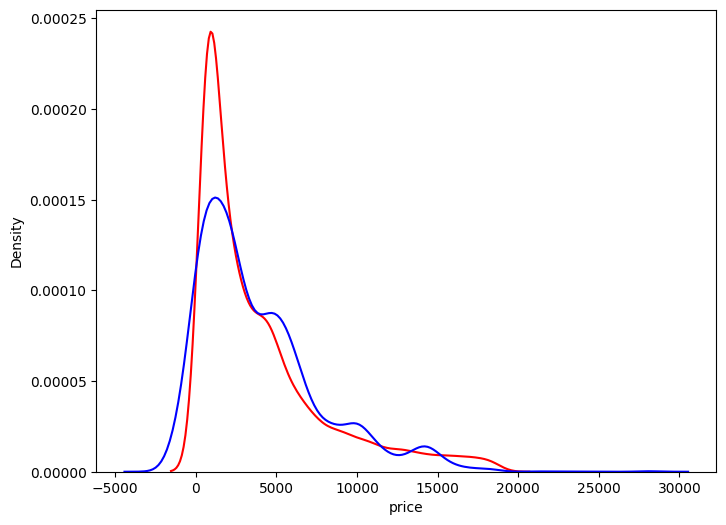

In [45]:
Yhat_mlrm = lr.predict(X_test)

plt.figure(figsize=(8,6))

ax1 =  sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(Yhat_mlrm, hist=False, color='Blue', ax=ax1, label='Predicted weight')

<Axes: xlabel='price', ylabel='Density'>

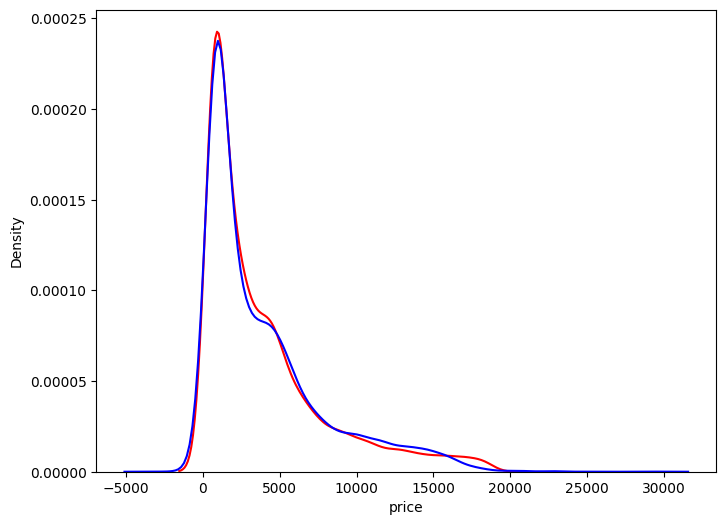

In [46]:
import warnings
warnings.filterwarnings("ignore")
Yhat_mlrm = poly_pipe.predict(X_test)

plt.figure(figsize=(8,6))

ax1 =  sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(Yhat_mlrm, hist=False, color='Blue', ax=ax1, label='Predicted weight')

Полиномиальная регрессия степени 2 хорошо предсказывает плотность распределения, немного отклоняясь при больших значениях

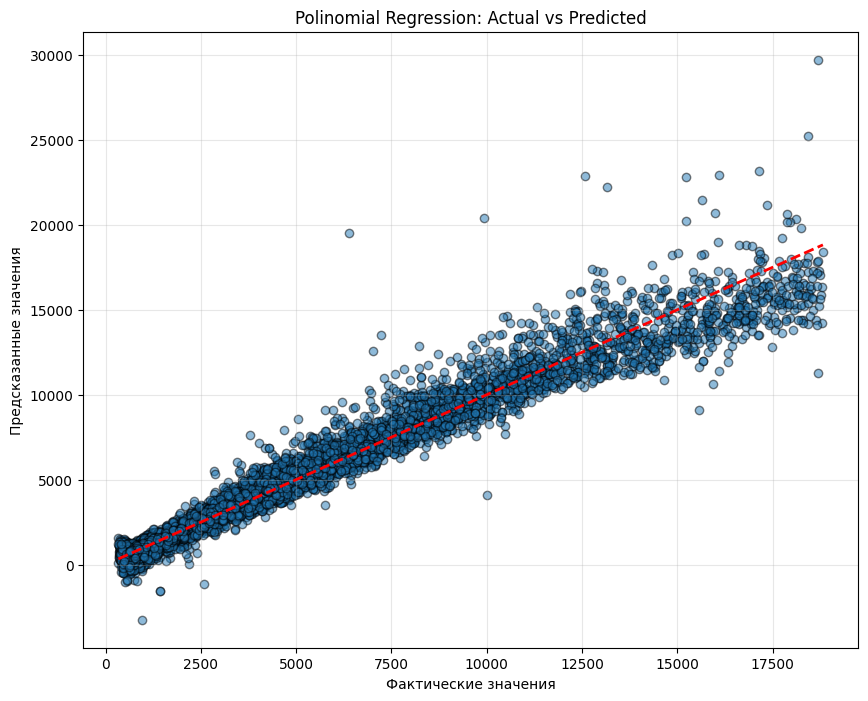

In [47]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Polinomial Regression: Actual vs Predicted')
plt.grid(True, alpha=0.3)
plt.show()

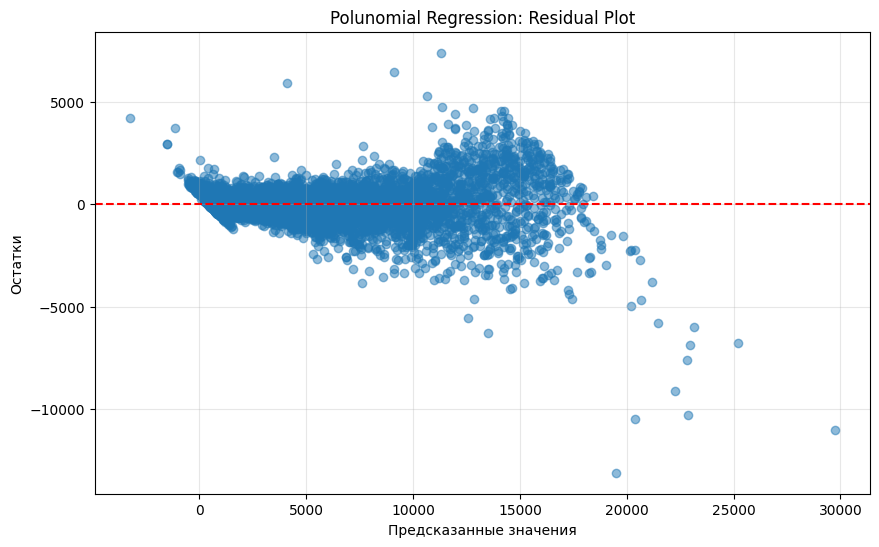

In [48]:
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Polunomial Regression: Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()

### Баесовская

In [49]:
bayesian_ridge = BayesianRidge()
bayesian_ridge.fit(X_train, y_train)

y_train_pred = bayesian_ridge.predict(X_train)
y_test_pred = bayesian_ridge.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.908812574260051, 'MSE': 1451679.9945161669, 'RMSE': 1204.8568356930075, 'MAE': 803.8208882123447, 'MAPE': 0.4380416439891491}
{'R^2': 0.9083089107408151, 'MSE': 1457596.8746247706, 'RMSE': 1207.3097674684698, 'MAE': 801.3034668485358, 'MAPE': 0.44426045881831316}


### Робастная

In [50]:
ransac = RANSACRegressor(estimator=LinearRegression(), random_state=42)
ransac.fit(X_train, y_train)

y_train_pred = ransac.predict(X_train)
y_test_pred = ransac.predict(X_test)

print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8376621181104429, 'MSE': 2584376.667933015, 'RMSE': 1607.5996603424048, 'MAE': 819.8860709447926, 'MAPE': 0.21975055138713936}
{'R^2': 0.8427808388335757, 'MSE': 2499284.933779457, 'RMSE': 1580.9126901190518, 'MAE': 799.5825297545127, 'MAPE': 0.22000426695735506}


## Визуализация

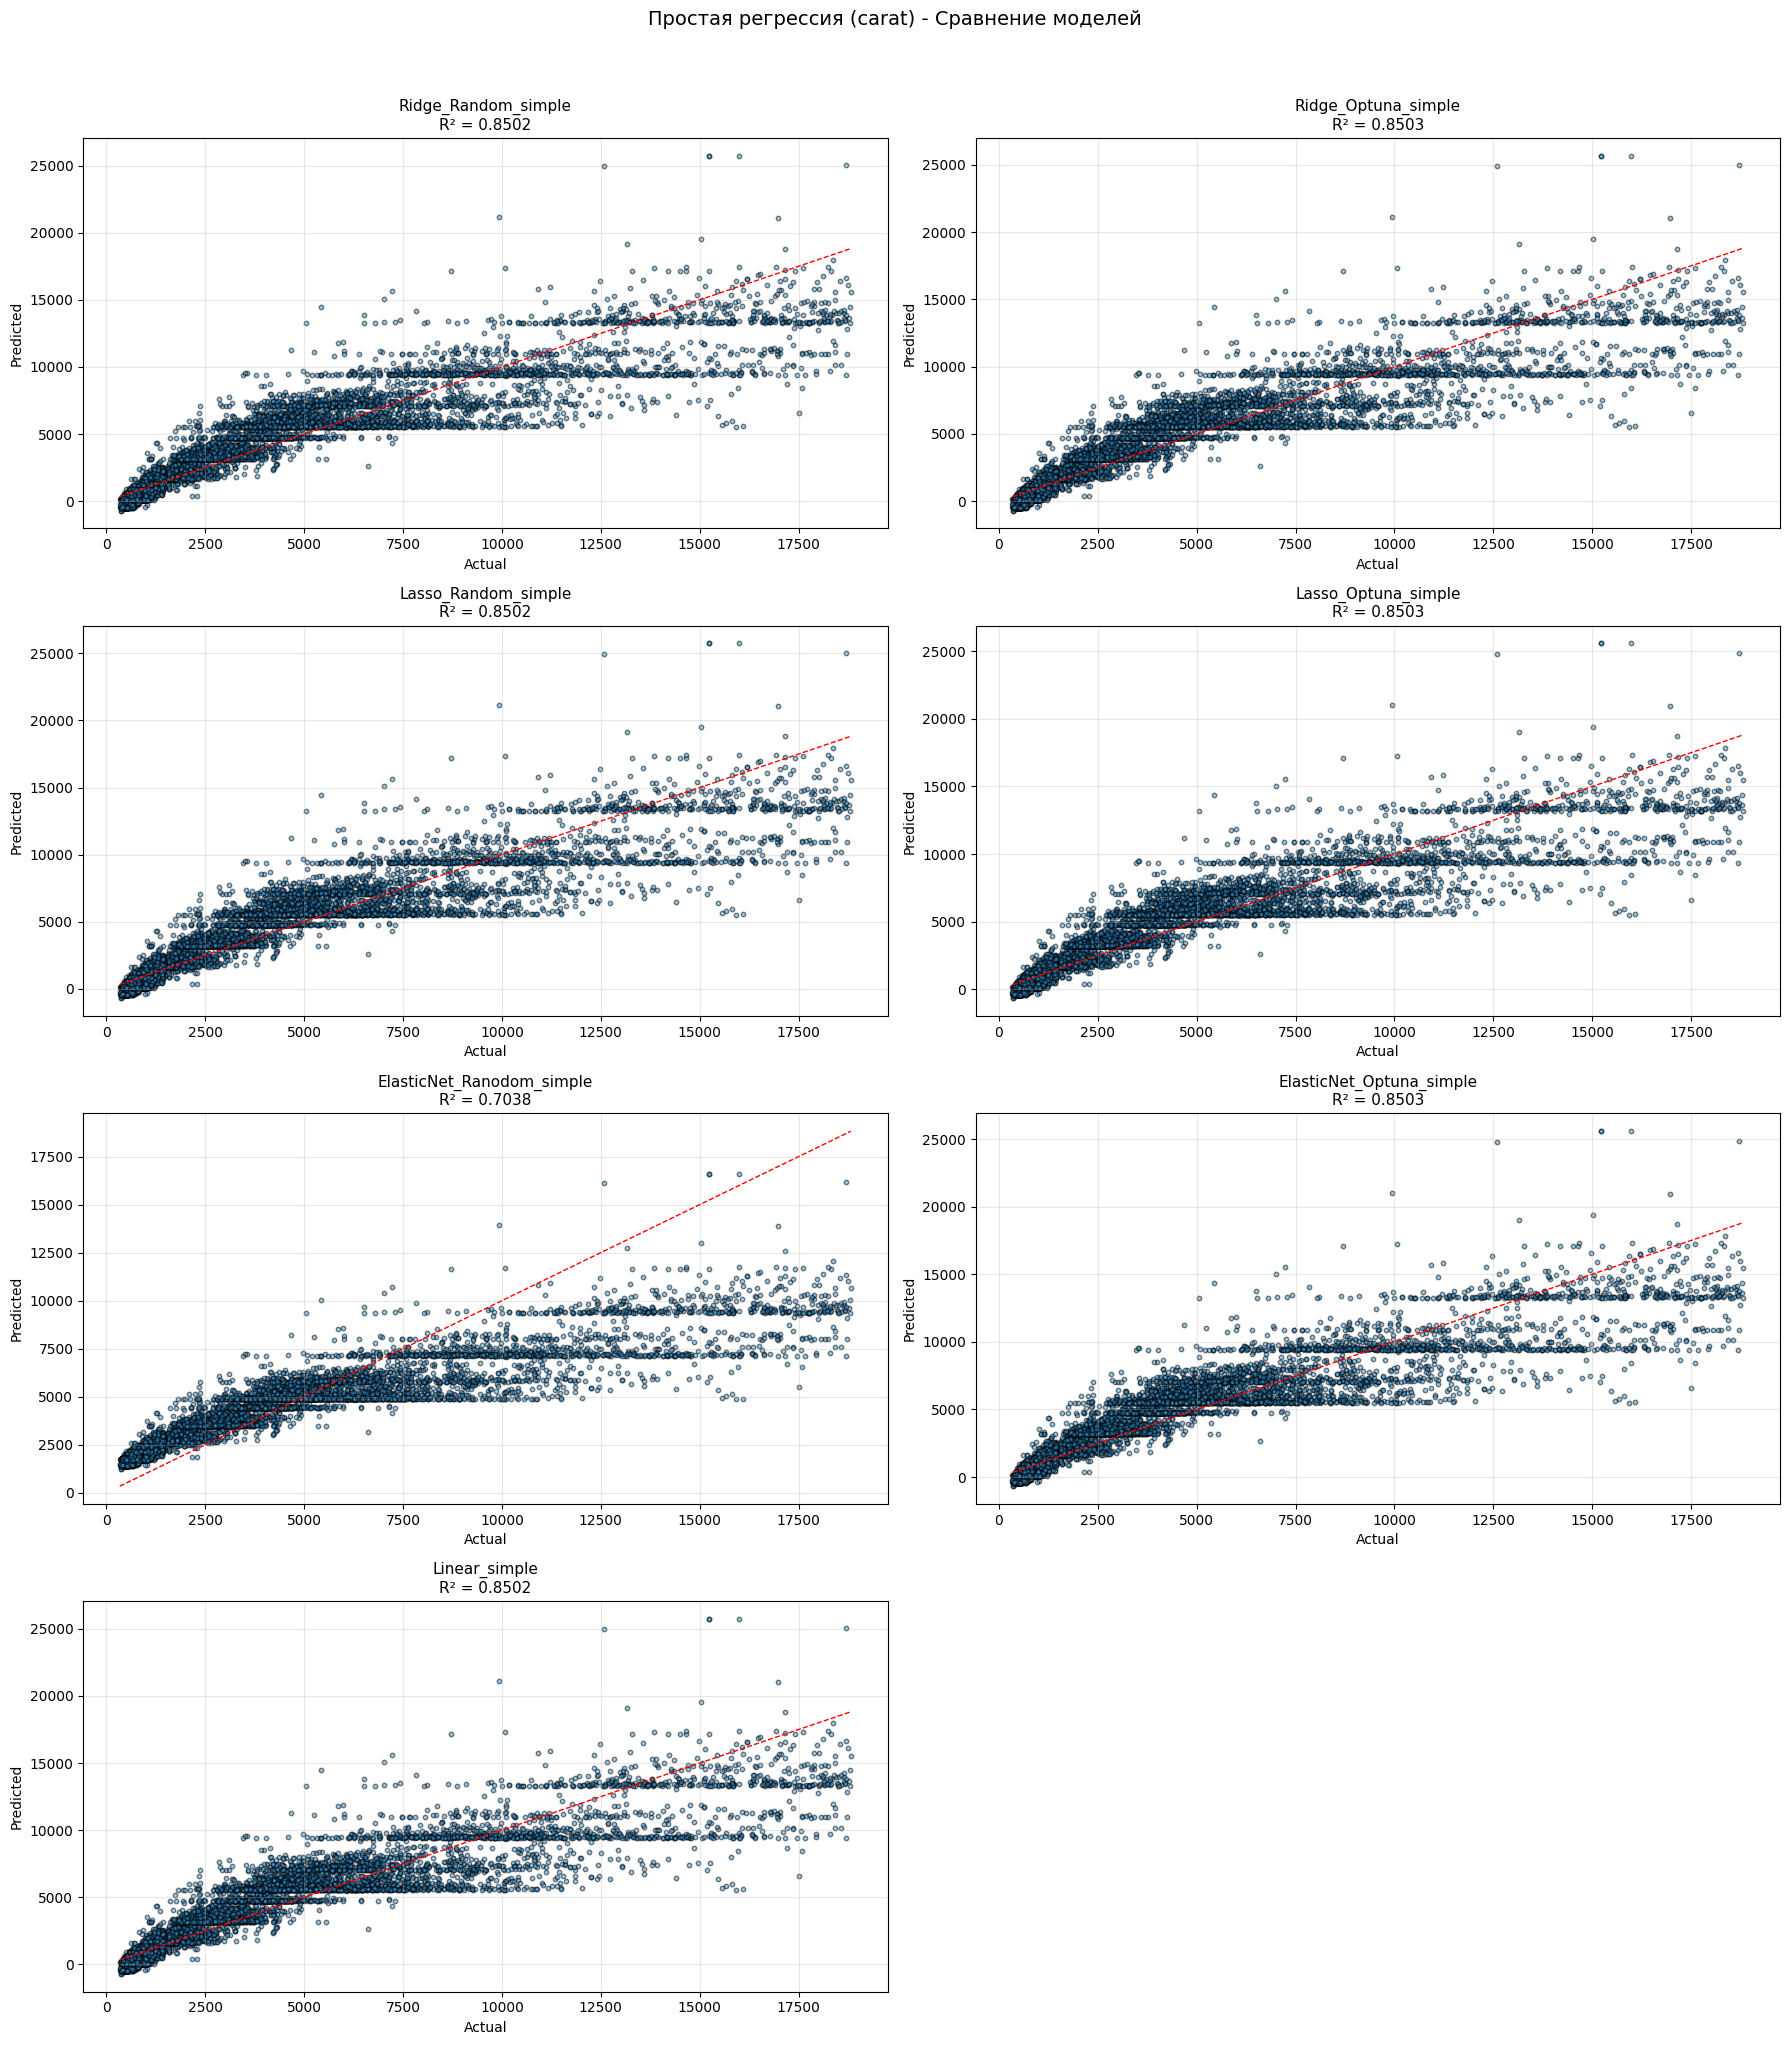

In [51]:
simple_models_preds = [
    ('Ridge_Random_simple', random_Ridge_simple.predict(X_test_simple)),
    ('Ridge_Optuna_simple', optuna_Ridge_simple.predict(X_test_simple)),
    ('Lasso_Random_simple', random_lasso_simple.predict(X_test_simple)),
    ('Lasso_Optuna_simple', optuna_lasso_simple.predict(X_test_simple)),
    ('ElasticNet_Ranodom_simple', random_ElasticNet_simple.predict(X_test_simple)),
    ('ElasticNet_Optuna_simple', optuna_ElasticNet_simple.predict(X_test_simple)),
    ('Linear_simple', lr_simple.predict(X_test_simple)),
]

n_models = len(simple_models_preds)
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(simple_models_preds):
    ax = axes[idx]
    
    ax.scatter(y_test, y_pred, alpha=0.5, s=10, edgecolors='k', c='#3498db')
    
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
    
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=11)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)

for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Простая регрессия (carat) - Сравнение моделей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

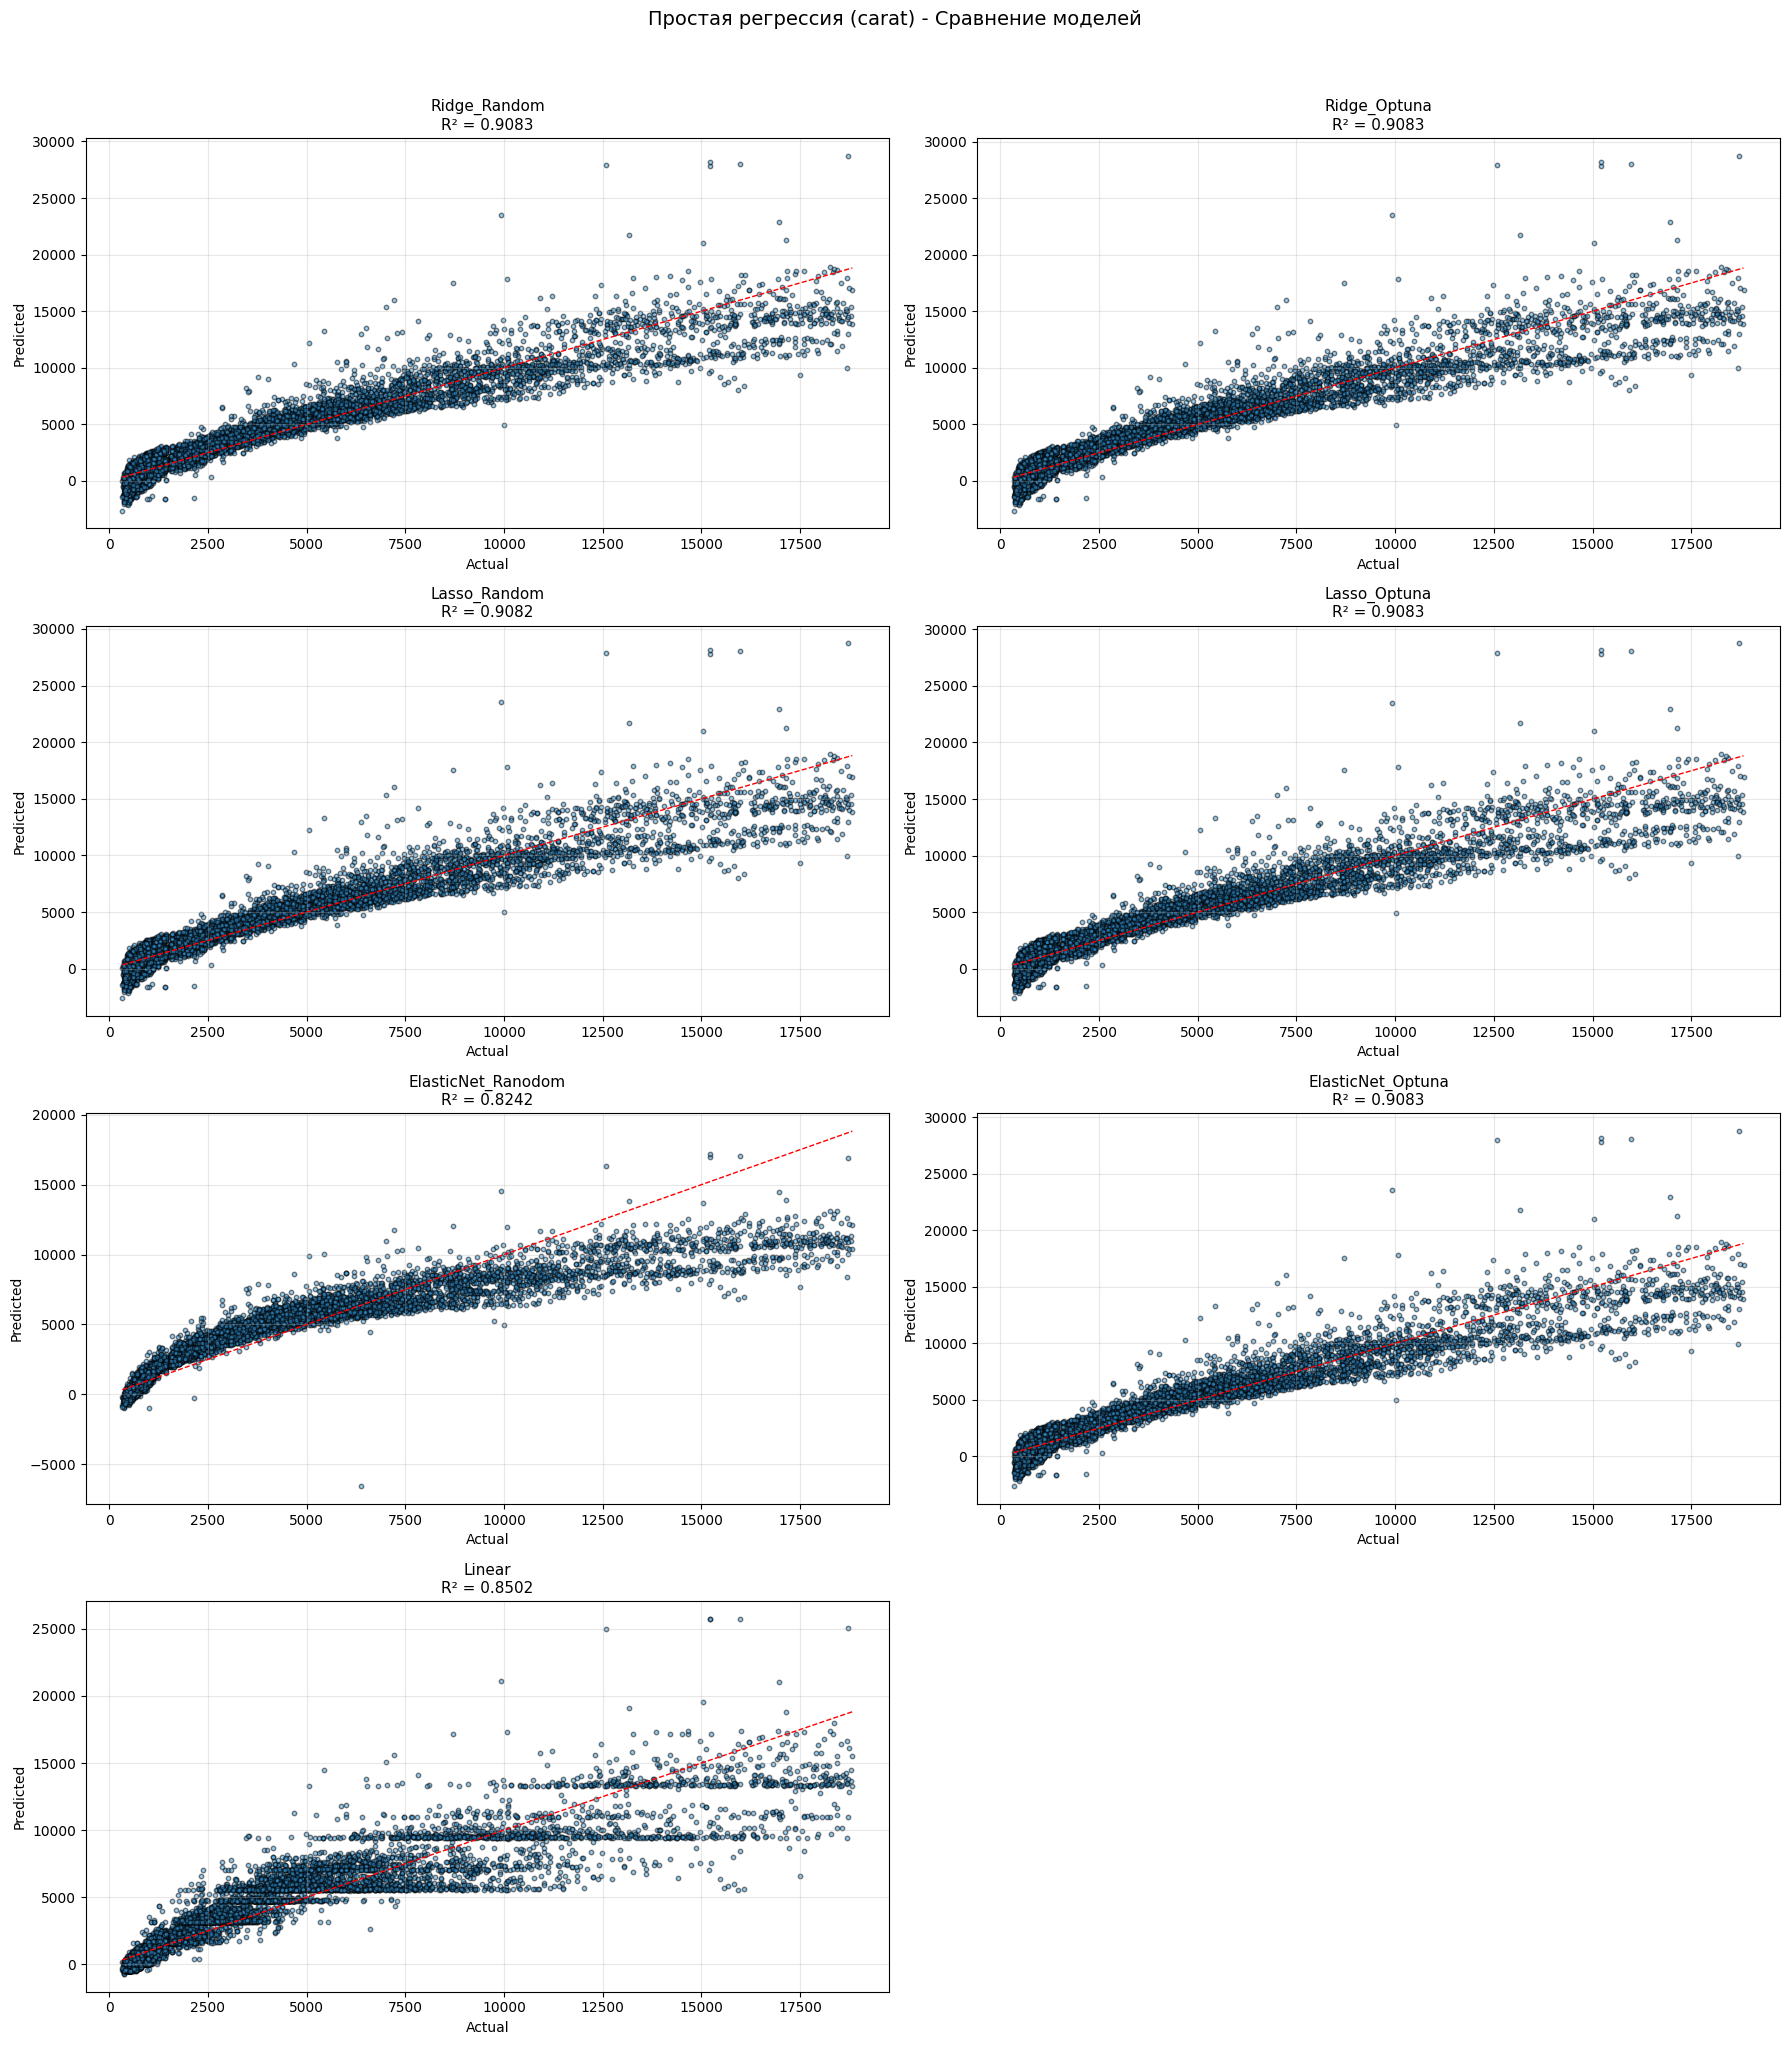

In [52]:
models_preds = [
    ('Ridge_Random', random_Ridge.predict(X_test)),
    ('Ridge_Optuna', optuna_Ridge.predict(X_test)),
    ('Lasso_Random', random_lasso.predict(X_test)),
    ('Lasso_Optuna', optuna_lasso.predict(X_test)),
    ('ElasticNet_Ranodom', random_ElasticNet.predict(X_test)),
    ('ElasticNet_Optuna', optuna_ElasticNet.predict(X_test)),
    ('Linear', lr_simple.predict(X_test_simple)),
]

n_models = len(models_preds)
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(models_preds):
    ax = axes[idx]
    
    ax.scatter(y_test, y_pred, alpha=0.5, s=10, edgecolors='k', c='#3498db')
    
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
    
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=11)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)

for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Простая регрессия (carat) - Сравнение моделей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Анализируя графики, можно сделать вывод, что `optuna` лучше справилась с поиском гиперпараметров, а значит именно её стоит а дальнейшем рассматривать при анализе

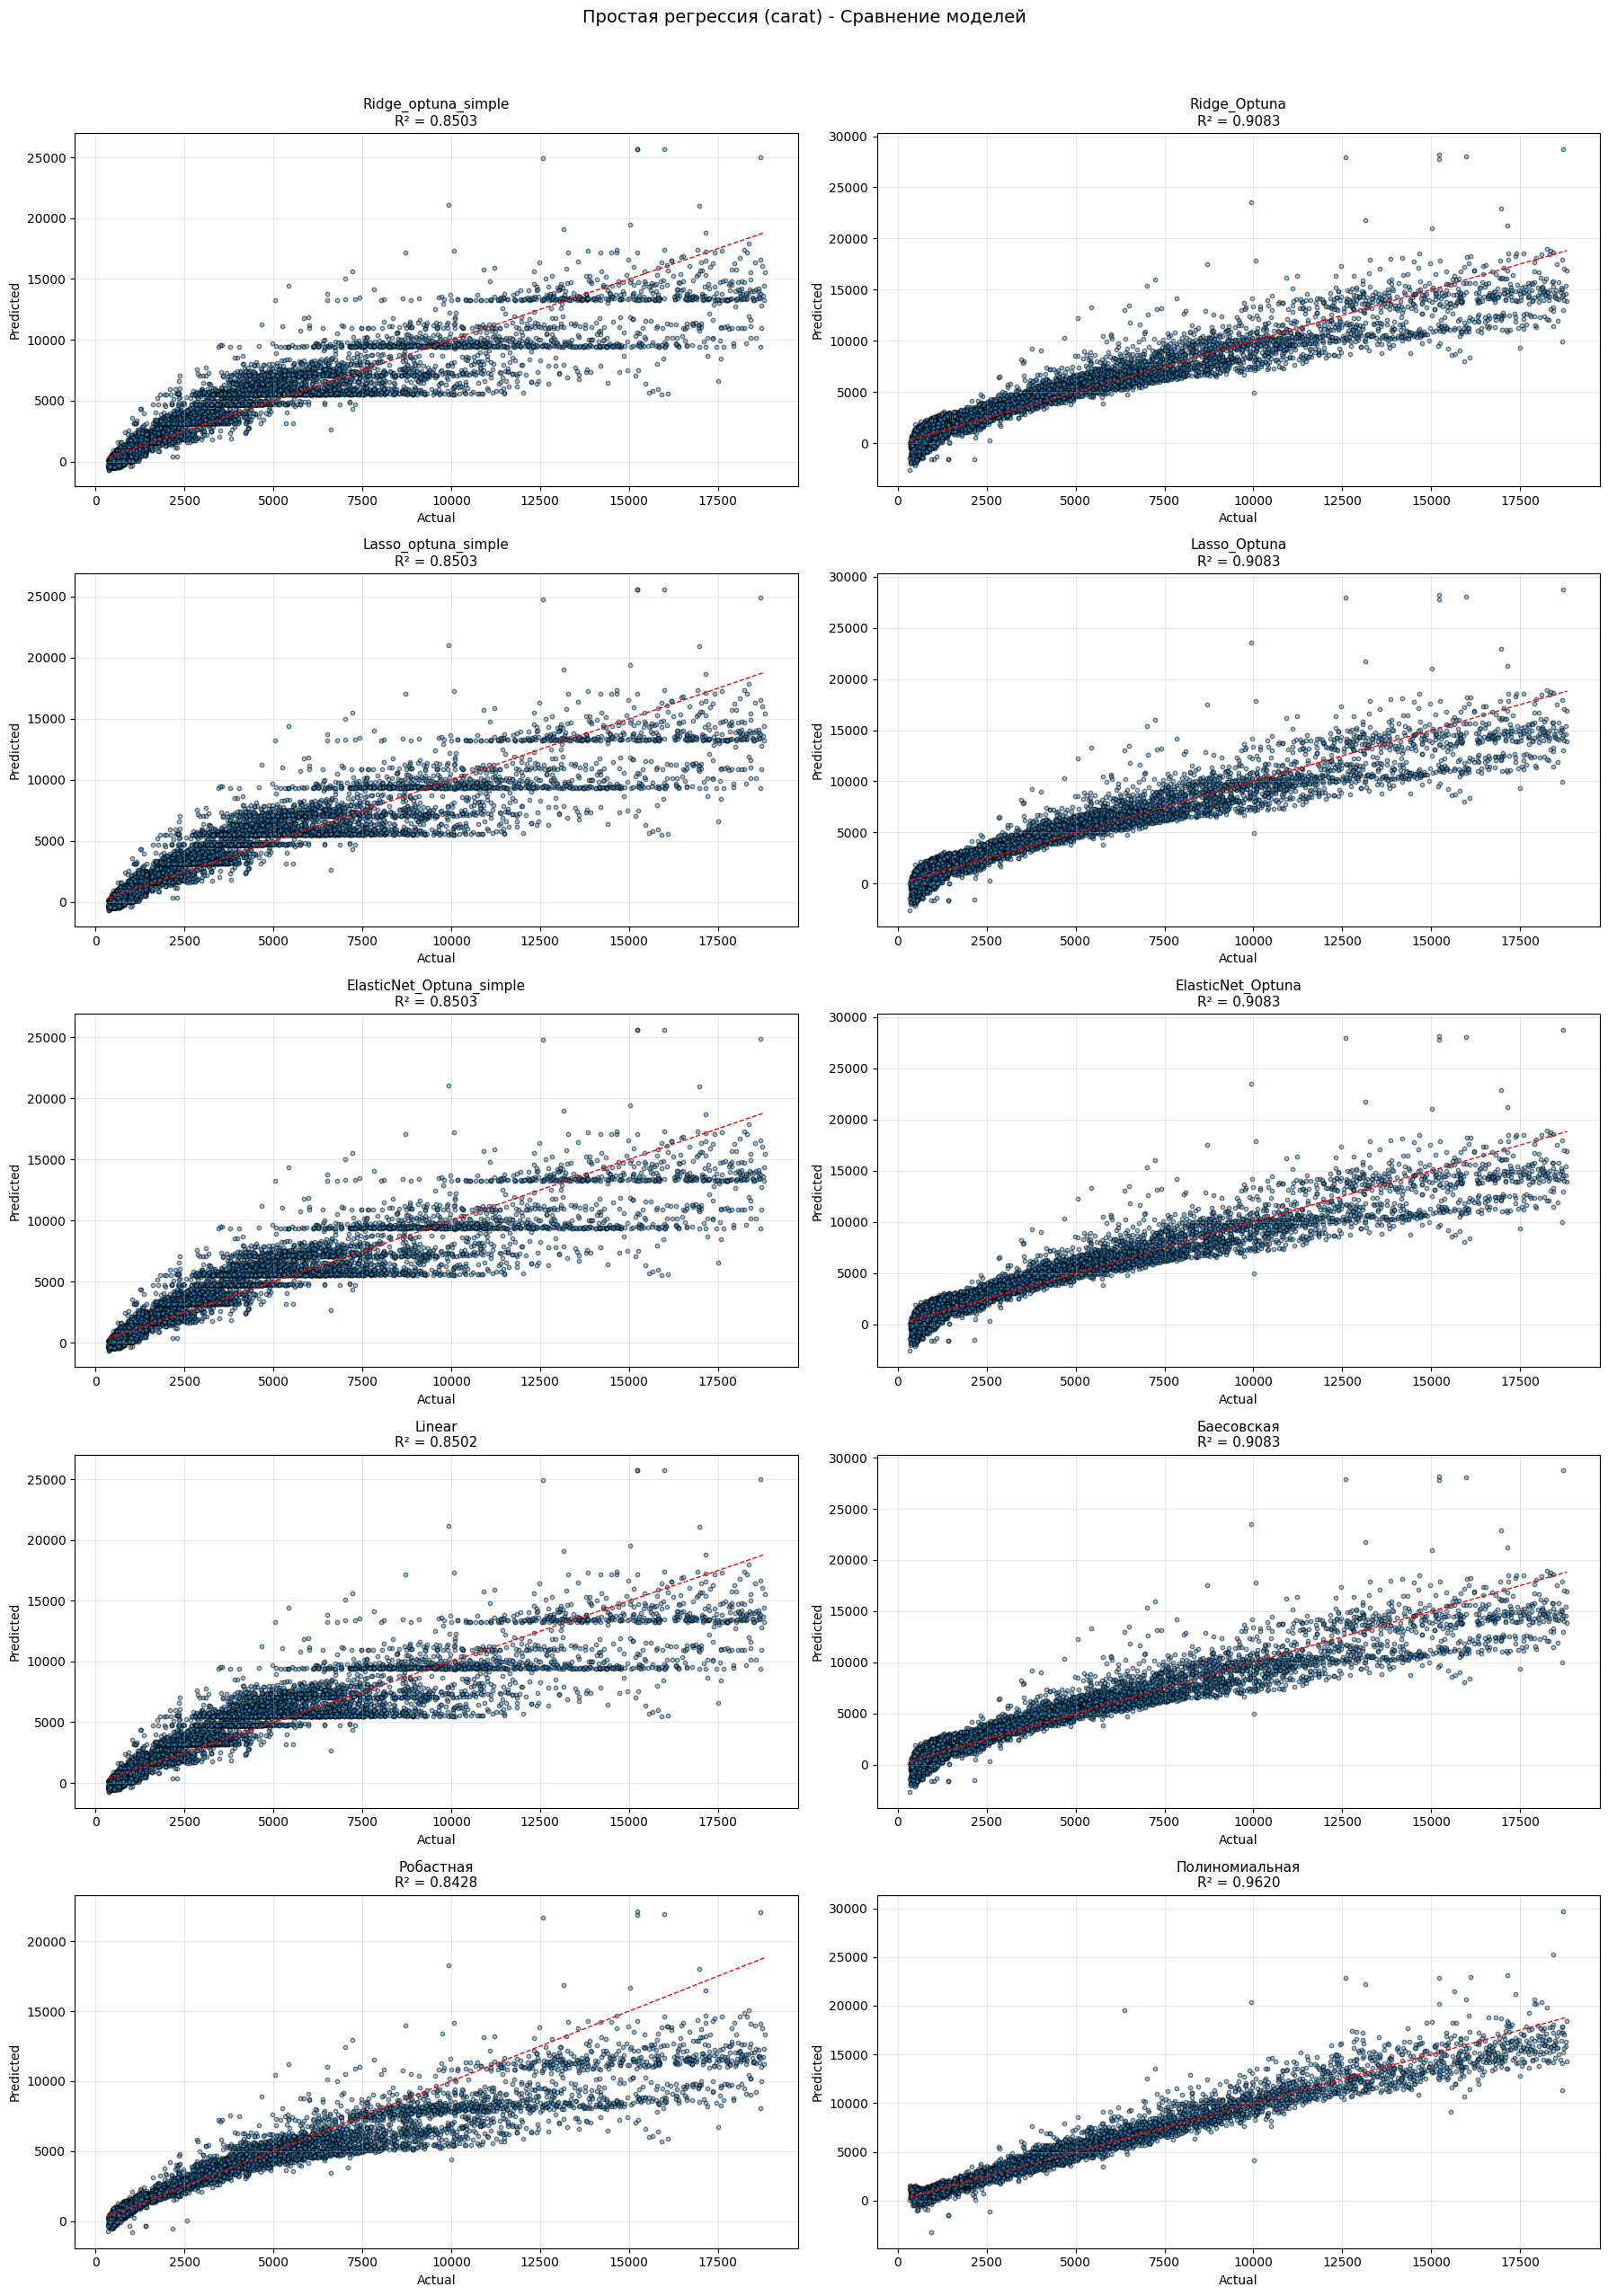

In [53]:
models_preds = [
    ('Ridge_optuna_simple', optuna_Ridge_simple.predict(X_test_simple)),
    ('Ridge_Optuna', optuna_Ridge.predict(X_test)),
    ('Lasso_optuna_simple', optuna_lasso_simple.predict(X_test_simple)),
    ('Lasso_Optuna', optuna_lasso.predict(X_test)),
    ('ElasticNet_Optuna_simple', optuna_ElasticNet_simple.predict(X_test_simple)),
    ('ElasticNet_Optuna', optuna_ElasticNet.predict(X_test)),
    ('Linear', lr_simple.predict(X_test_simple)),
    ('Баесовская', bayesian_ridge.predict(X_test)),
    ('Робастная', ransac.predict(X_test)),
    ('Полиномиальная', poly_pipe.predict(X_test)),
]

n_models = len(models_preds)
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(models_preds):
    ax = axes[idx]
    
    ax.scatter(y_test, y_pred, alpha=0.5, s=10, edgecolors='k', c='#3498db')
    
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
    
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=11)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)

for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Простая регрессия (carat) - Сравнение моделей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

По визаульному анализу полинмиальаня регрессия справилась лучше остальных

## Самостоятельная реализация функций

In [54]:
# import sys
# from metrics import *

# это в сторонем файле

__all__ = ["mae_custom", "mse_custom", "rmse_custom", "mape_custom", "r2_custom", "custom_calculate_metrics"]

def mae_custom(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse_custom(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse_custom(y_true, y_pred):
    return np.sqrt(mse_custom(y_true, y_pred))

def mape_custom(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

def r2_custom(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def custom_calculate_metrics(y_true, y_pred):
    return {
        'R^2': r2_custom(y_true, y_pred),
        'MSE': mse_custom(y_true, y_pred),
        'RMSE': rmse_custom(y_true, y_pred),
        'MAE': mae_custom(y_true, y_pred),
        'MAPE': mape_custom(y_true, y_pred)
    }

In [55]:
all_models = {
    'Linear_Multi': lr,
    'Linear_Simple': lr_simple,

    'Ridge_Multi': optuna_Ridge,
    'Ridge_Simple': optuna_Ridge_simple,

    'Lasso_Multi': optuna_lasso,
    'Lasso_Simple': optuna_lasso_simple,

    'ElasticNet_Multi': optuna_ElasticNet,
    'ElasticNet_Simple': optuna_ElasticNet_simple,

    'Polynomial': poly_pipe,
    'BayesianRidge': bayesian_ridge,
    'RANSAC': ransac,
}

model_data = {
    'Linear_Multi': (X_train, X_test),
    'Ridge_Multi': (X_train, X_test),
    'Lasso_Multi': (X_train, X_test),
    'ElasticNet_Multi': (X_train, X_test),
    'BayesianRidge': (X_train, X_test),
    'RANSAC': (X_train, X_test),
    'Polynomial': (X_train, X_test),
    'Linear_Simple': (X_train_simple, X_test_simple),
    'Ridge_Simple': (X_train_simple, X_test_simple),
    'Lasso_Simple': (X_train_simple, X_test_simple),
    'ElasticNet_Simple': (X_train_simple, X_test_simple)
}

results = []

for model_name, model in all_models.items():
    X_tr, X_te = model_data[model_name]
    
    train_metrics = calculate_metrics(y_train, model.predict(X_tr))
    test_metrics = calculate_metrics(y_test, model.predict(X_te))
    
    results.append({
        'Регрессор': model_name,
        'Train': {
            'R^2': train_metrics['R^2'],
            'MSE': train_metrics['MSE'],
            'RMSE': train_metrics['RMSE'],
            'MAE': train_metrics['MAE'],
            'MAPE': train_metrics['MAPE']
        },
        'Test': {
            'R^2': test_metrics['R^2'],
            'MSE': test_metrics['MSE'],
            'RMSE': test_metrics['RMSE'],
            'MAE': test_metrics['MAE'],
            'MAPE': test_metrics['MAPE']
        }
    })

df_train = pd.DataFrame([r['Train'] for r in results])
df_test = pd.DataFrame([r['Test'] for r in results])

final_metrics = pd.concat({
    'Train Data': df_train,
    'Test Data': df_test
}, axis=1)

final_metrics.insert(0, 'Регрессор', [r['Регрессор'] for r in results])

final_metrics = final_metrics.sort_values(
    ('Test Data', 'R^2'), 
    ascending=False
)

final_metrics = final_metrics.style.format({
    ('Train Data', 'R^2'): '{:.2f}',
    ('Train Data', 'MSE'): '{:.4f}',
    ('Train Data', 'RMSE'): '{:.4f}',
    ('Train Data', 'MAE'): '{:.4f}',
    ('Train Data', 'MAPE'): '{:.4f}',
    ('Test Data', 'R^2'): '{:.2f}',
    ('Test Data', 'MSE'): '{:.4f}',
    ('Test Data', 'RMSE'): '{:.4f}',
    ('Test Data', 'MAE'): '{:.4f}',
    ('Test Data', 'MAPE'): '{:.4f}',
})

final_metrics

Исходя из статистик можно сказать, что:

- много модели множественной регресси справляются лучше, чем простая
- Наилучший результат показала полиномиальная регрессия
- Все модели показали хороший рехультат (R^2 не меньше 0.84)
- Все модели показывают стабильность - нет переобучения

In [56]:
all_models = {
    'Linear_Multi': lr,
    'Linear_Simple': lr_simple,

    'Ridge_Multi': optuna_Ridge,
    'Ridge_Simple': optuna_Ridge_simple,

    'Lasso_Multi': optuna_lasso,
    'Lasso_Simple': optuna_lasso_simple,

    'ElasticNet_Multi': optuna_ElasticNet,
    'ElasticNet_Simple': optuna_ElasticNet_simple,

    'Polynomial': poly_pipe,
    'BayesianRidge': bayesian_ridge,
    'RANSAC': ransac,
}

model_data = {
    'Linear_Multi': (X_train, X_test),
    'Ridge_Multi': (X_train, X_test),
    'Lasso_Multi': (X_train, X_test),
    'ElasticNet_Multi': (X_train, X_test),
    'BayesianRidge': (X_train, X_test),
    'RANSAC': (X_train, X_test),
    'Polynomial': (X_train, X_test),
    'Linear_Simple': (X_train_simple, X_test_simple),
    'Ridge_Simple': (X_train_simple, X_test_simple),
    'Lasso_Simple': (X_train_simple, X_test_simple),
    'ElasticNet_Simple': (X_train_simple, X_test_simple)
}

results = []

for model_name, model in all_models.items():
    X_tr, X_te = model_data[model_name]
    
    scipy_metrics = calculate_metrics(y_train, model.predict(X_tr))
    custom_metrics = custom_calculate_metrics(y_train, model.predict(X_tr))
    
    results.append({
        'Регрессор': model_name,
        'Scikit-learn': {
            'R^2': scipy_metrics['R^2'],
            'MSE': scipy_metrics['MSE'],
            'RMSE': scipy_metrics['RMSE'],
            'MAE': scipy_metrics['MAE'],
            'MAPE': scipy_metrics['MAPE']
        },
        'Кастомные функии': {
            'R^2': custom_metrics['R^2'],
            'MSE': custom_metrics['MSE'],
            'RMSE': custom_metrics['RMSE'],
            'MAE': custom_metrics['MAE'],
            'MAPE': custom_metrics['MAPE']
        }
    })

df_Scikit = pd.DataFrame([r['Scikit-learn'] for r in results])
df_custom  = pd.DataFrame([r['Кастомные функии'] for r in results])

final_metrics_df = pd.concat({
    'Scikit-learn': df_Scikit,
    'Кастомные функии': df_custom
}, axis=1)

final_metrics_df.insert(0, 'Регрессор', [r['Регрессор'] for r in results])

final_metrics = final_metrics_df.style.format({
    ('Scikit-learn', 'R^2'): '{:.2f}',
    ('Scikit-learn', 'RMSE'): '{:.4f}',
    ('Scikit-learn', 'MAE'): '{:.4f}',
    ('Scikit-learn', 'MAPE'): '{:.4f}',
    ('Кастомные функии', 'R^2'): '{:.2f}',
    ('Кастомные функии', 'MSE'): '{:.4f}',
    ('Кастомные функии', 'RMSE'): '{:.4f}',
    ('Кастомные функии', 'MAE'): '{:.4f}',
    ('Кастомные функии', 'MAPE'): '{:.4f}',
})

final_metrics

Значение встроенных функций scikit и самописных совпадают

## Восстановление уравнения

In [57]:
coef = poly_pipe.named_steps['model'].coef_
intercept = poly_pipe.named_steps['model'].intercept_

poly = poly_pipe.named_steps['poly']
feature_names = poly.get_feature_names_out()

print("Коэффициенты:", coef)
print("Признаки:", feature_names)
print(*zip(feature_names, coef))
print("Интерцепт:", intercept)

def compact_equation(coef_dict, intercept, precision=2):
    terms = []
    
    for term, coef in sorted(coef_dict.items(), key=lambda x: x[1], reverse=True):
        if abs(coef) < 1e-6:
            continue
            
        if '^2' in term:
            term_str = term
        elif ' ' in term:
            term_str = term.replace(' ', '·')
        else:
            term_str = term
        
        if coef > 0:
            terms.append(f"+ {coef:.{precision}f}{term_str}")
        else:
            terms.append(f"- {abs(coef):.{precision}f}{term_str}")
    
    first_term = terms[0]
    if first_term.startswith('+'):
        first_term = first_term[2:]
    elif first_term.startswith('-'):
        first_term = '-' + first_term[2:]
    
    result = f"y = {intercept:.{precision}f} + " + " ".join([first_term] + terms[1:])
    return result

compact_equation({feature_names[i]: coef[i] for i in range(len(coef))}, intercept)

Коэффициенты: [ 5.80479151e+03  8.33538291e+01  5.71510207e+02  9.10264727e+02
 -1.70245448e+02 -6.69021881e+01 -1.57345633e+03 -5.94514476e+02
  6.32270679e+02 -5.54516172e+02  4.03008461e+02  3.44946977e+02
  1.13139719e+03 -4.33737850e+01  1.84596806e+02 -2.25849168e+03
  1.64052120e+03  1.73068448e+03  8.26537276e+00  3.61169986e+01
 -5.37211602e-01 -3.92068932e+01 -1.31525106e+01 -8.15628978e+02
  2.05212432e+02  3.28011069e+02 -7.54955733e+01  3.38561123e+02
  4.94753150e+01  4.72157306e+00 -8.92455154e+00  5.38540617e+02
 -2.50499369e+02 -5.76554121e+00 -9.89350509e+00 -3.50020627e+01
  6.42585625e+02 -7.54503821e+02 -8.23049355e+01 -2.54471180e+01
 -2.57626796e+01  1.89200007e+02  1.32106383e+02 -1.18239881e+02
 -1.60427723e+01  3.41681166e+02 -6.61578151e+02  1.22828982e+02
 -1.17703694e+03  2.70748322e+03  5.16356310e+02  1.34233386e+03
 -3.24751998e+03 -6.81469091e+01]
Признаки: ['x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x0^2' 'x0 x1' 'x0 x2'
 'x0 x3' 'x0 x4' 'x0 x5' 'x0

'y = 3970.76 + 5804.79x0 + 2707.48x6·x7 + 1730.68x0·x8 + 1640.52x0·x7 + 1342.33x7^2 + 1131.40x0·x3 + 910.26x3 + 642.59x3·x6 + 632.27x8 + 571.51x2 + 538.54x2·x7 + 516.36x6·x8 + 403.01x0·x1 + 344.95x0·x2 + 341.68x5·x6 + 338.56x2·x3 + 328.01x1·x8 + 205.21x1·x7 + 189.20x4·x6 + 184.60x0·x5 + 132.11x4·x7 + 122.83x5·x8 + 83.35x1 + 49.48x2·x4 + 36.12x1·x2 + 8.27x1^2 + 4.72x2·x5 - 0.54x1·x3 - 5.77x3^2 - 8.92x2·x6 - 9.89x3·x4 - 13.15x1·x5 - 16.04x5^2 - 25.45x4^2 - 25.76x4·x5 - 35.00x3·x5 - 39.21x1·x4 - 43.37x0·x4 - 66.90x5 - 68.15x8^2 - 75.50x2^2 - 82.30x3·x8 - 118.24x4·x8 - 170.25x4 - 250.50x2·x8 - 554.52x0^2 - 594.51x7 - 661.58x5·x7 - 754.50x3·x7 - 815.63x1·x6 - 1177.04x6^2 - 1573.46x6 - 2258.49x0·x6 - 3247.52x7·x8'

## Вывод

В ходе работы были рассмотрены 3 способа поиска гиперпараметров (`GridSearchCV`, `RandomizedSearchCV`,  фреймворк `Optuna`). Именно `optuna` показал чуть лучший результат, при этом другие 2 алгоритма расчитали одиннаковые гиперпараметры

Были рассмотрены простая и множественная регрессия. Множественная регрессия показала результат лучше

Были рассмотрены разные методы (linnear, Lassp, Ridge, ElasticNet, PolynomialFeatures, BayesianRidge, RANSACRegressor (один из 3 представителей робастной регресии)). Среди них лучший результат показала полиномиальная регрессия `degree` = 2. Об этот свидетельствует наибольший показатель R^2 и меньшие остальные метрики. Все модели стабильны, показав минимальнубю разницу между train и test данными. Но при этом RANSAC имеет меньший среди остальных линейных моделей показатель `MAPE`, хотя маленький `R^2`. Она лучше предсказывает типичные данные, но имеет проблемы с особенными (аномалиями) значениями

Использованы методы визуализации (графики и таблица), необходимые для анализа, и функции высчитывающие метрики (из библиотеки scikit и собственного написания)

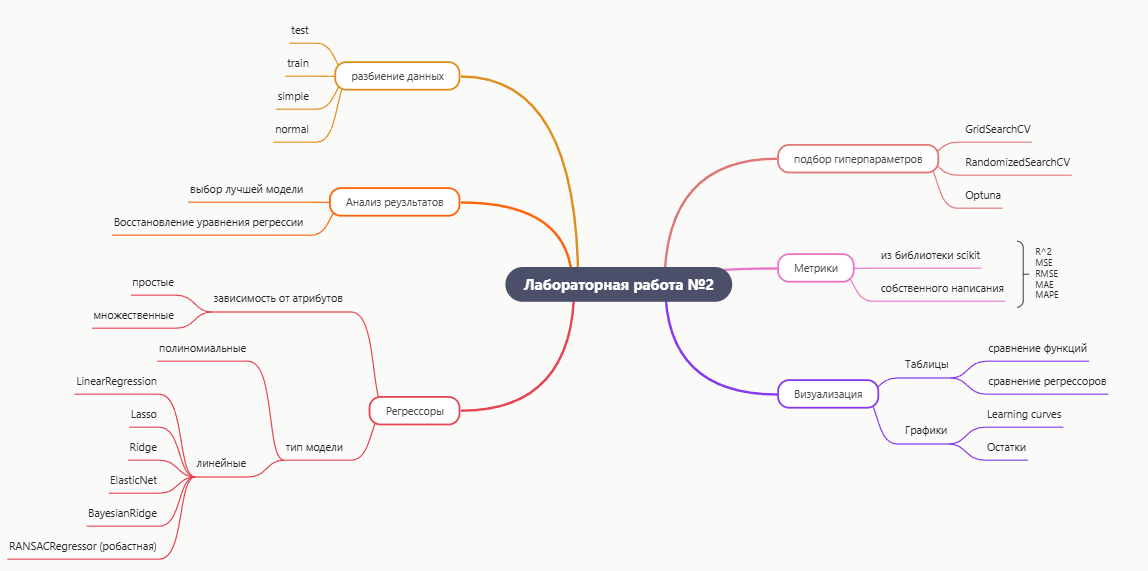